# EDA

## Análise

## Quais aeroportos são mais críticos em relação a atrasos?



In [1]:
# =====================================================
# Setup
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
# =====================================================
# Load Data
# =====================================================

flights_path = "../data/curated/flights/flights.parquet"
airports_path = "../data/curated/airports/airports.parquet"

df_flights = pd.read_parquet(flights_path)
df_airports = pd.read_parquet(airports_path)

print("Flights shape:", df_flights.shape)
print("Airports shape:", df_airports.shape)

df_flights.head()

Flights shape: (5332914, 32)
Airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,DELAY_RATIO
0,2015,1,1,4,AS,98,ANC,SEA,5,1434,-11.0,21.0,15,205.0,194.0,169.0,1448.0,244,4.0,270,248,-22.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.053659
1,2015,1,1,4,AA,2336,LAX,PBI,10,2,-8.0,12.0,14,280.0,279.0,263.0,2330.0,457,4.0,470,461,-9.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.028571
2,2015,1,1,4,US,840,SFO,CLT,20,18,-2.0,16.0,34,286.0,293.0,266.0,2296.0,480,11.0,486,491,5.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.006993
3,2015,1,1,4,AA,258,LAX,MIA,20,15,-5.0,15.0,30,285.0,281.0,258.0,2342.0,468,8.0,485,476,-9.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.017544
4,2015,1,1,4,AS,135,SEA,ANC,25,24,-1.0,11.0,35,235.0,215.0,199.0,1448.0,174,5.0,200,179,-21.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.004255


In [3]:
# =====================================================
# Seleção de colunas relevantes
# =====================================================

cols = [
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "CANCELLED"
]

df = df_flights[cols].copy()

df.head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ARRIVAL_DELAY,DEPARTURE_DELAY,CANCELLED
0,ANC,SEA,-22.0,-11.0,0
1,LAX,PBI,-9.0,-8.0,0
2,SFO,CLT,5.0,-2.0,0
3,LAX,MIA,-9.0,-5.0,0
4,SEA,ANC,-21.0,-1.0,0


In [4]:
# =====================================================
# Limpeza
# =====================================================

# Remover cancelados
df = df[df["CANCELLED"] == 0]

# Remover nulos
df = df.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

# Criar flag de atraso (>= 15 min é padrão mercado)
df["IS_DELAYED"] = df["ARRIVAL_DELAY"] > 15

df.describe()

,ARRIVAL_DELAY,DEPARTURE_DELAY,CANCELLED
count,5.245484e+06,5.245484e+06,5245484.0
mean,4.872533e+00,9.741562e+00,0.0
std,3.973362e+01,3.750172e+01,0.0
min,-8.700000e+01,-8.200000e+01,0.0
25%,-1.300000e+01,-5.000000e+00,0.0
50%,-5.000000e+00,-1.000000e+00,0.0
75%,8.000000e+00,8.000000e+00,0.0
max,1.971000e+03,1.988000e+03,0.0


In [5]:
# =====================================================
# Agregação por aeroporto de origem
# =====================================================

airport_metrics = (
    df.groupby("ORIGIN_AIRPORT")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean"),
        avg_departure_delay=("DEPARTURE_DELAY", "mean"),
        delay_rate=("IS_DELAYED", "mean")
    )
    .reset_index()
)

# Converter delay_rate para percentual
airport_metrics["delay_rate"] = airport_metrics["delay_rate"] * 100

airport_metrics.head()

,ORIGIN_AIRPORT,total_flights,avg_arrival_delay,avg_departure_delay,delay_rate
0,ABE,2235,6.227293,8.840268,17.136465
1,ABI,2232,3.270609,5.744175,15.322581
2,ABQ,18980,4.752687,8.858588,17.239199
3,ABR,663,9.909502,10.101056,17.345400
4,ABY,867,7.579008,8.880046,17.301038


In [6]:
# =====================================================
# Join com airports
# =====================================================

df_airports.columns = df_airports.columns.str.upper()

airport_metrics = airport_metrics.merge(
    df_airports,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

airport_metrics.head()

,ORIGIN_AIRPORT,total_flights,avg_arrival_delay,avg_departure_delay,delay_rate,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,2235,6.227293,8.840268,17.136465,ABE,Lehigh Valley International Airport,Allentown,Pa,Usa,40.65236,-75.44040
1,ABI,2232,3.270609,5.744175,15.322581,ABI,Abilene Regional Airport,Abilene,Tx,Usa,32.41132,-99.68190
2,ABQ,18980,4.752687,8.858588,17.239199,ABQ,Albuquerque International Sunport,Albuquerque,Nm,Usa,35.04022,-106.60919
3,ABR,663,9.909502,10.101056,17.345400,ABR,Aberdeen Regional Airport,Aberdeen,Sd,Usa,45.44906,-98.42183
4,ABY,867,7.579008,8.880046,17.301038,ABY,Southwest Georgia Regional Airport,Albany,Ga,Usa,31.53552,-84.19447


In [7]:
# =====================================================
# Ranking de criticidade
# =====================================================

# Score simples (você pode evoluir depois)
airport_metrics["critical_score"] = (
    airport_metrics["delay_rate"] * np.log1p(airport_metrics["total_flights"])
)

top_critical = airport_metrics.sort_values(
    by="critical_score",
    ascending=False
).head(15)

top_critical[[
    "ORIGIN_AIRPORT",
    "AIRPORT",
    "CITY",
    "STATE",
    "total_flights",
    "delay_rate",
    "avg_arrival_delay"
]]

,ORIGIN_AIRPORT,AIRPORT,CITY,STATE,total_flights,delay_rate,avg_arrival_delay
228,ORD,Chicago O'Hare International Airport,Chicago,Il,277336,23.312877,8.576539
182,LGA,Laguardia Airport (Marine Air Terminal),New York,Ny,95074,23.188253,5.613932
85,DEN,Denver International Airport,Denver,Co,193932,21.552915,7.168265
86,DFW,Dallas/Fort Worth International Airport,Dallas-Fort Worth,Tx,233297,20.863106,6.899682
203,MIA,Miami International Airport,Miami,Fl,68558,22.287698,7.014411
51,BWI,Baltimore-Washington International Airport,Baltimore,Md,84546,21.686419,7.229827
176,LAX,Los Angeles International Airport,Los Angeles,Ca,192509,20.072828,5.708377
166,JFK,John F. Kennedy International Airport (New Yor...,New York,Ny,91889,21.360555,3.598646
151,IAH,George Bush Intercontinental Airport,Houston,Tx,144492,20.473106,7.354116
106,EWR,Newark Liberty International Airport,Newark,Nj,98662,20.832742,4.471134


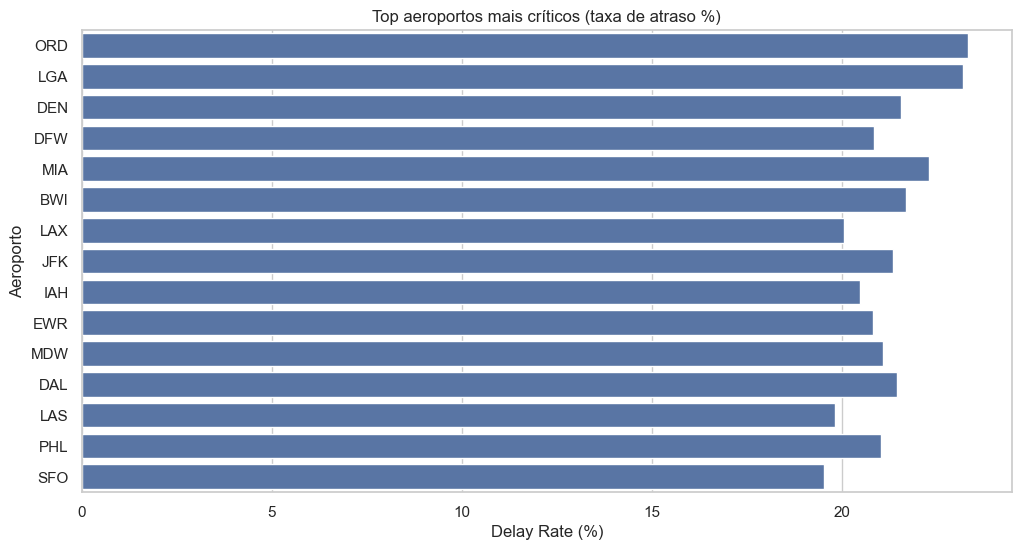

In [8]:
# =====================================================
# Gráfico - aeroportos críticos
# =====================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_critical,
    x="delay_rate",
    y="ORIGIN_AIRPORT"
)

plt.title("Top aeroportos mais críticos (taxa de atraso %)")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Aeroporto")

plt.show()

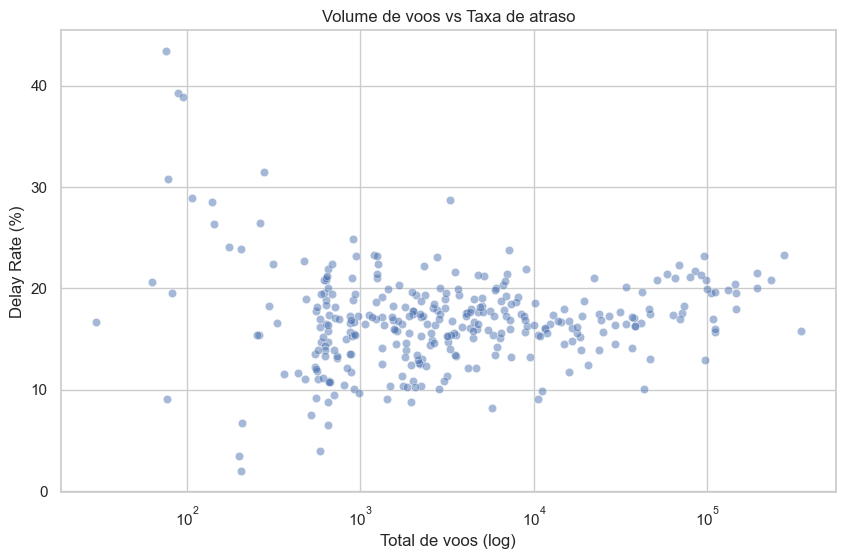

In [9]:
# =====================================================
# Scatter: volume vs atraso
# =====================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=airport_metrics,
    x="total_flights",
    y="delay_rate",
    alpha=0.5
)

plt.xscale("log")

plt.title("Volume de voos vs Taxa de atraso")
plt.xlabel("Total de voos (log)")
plt.ylabel("Delay Rate (%)")

plt.show()

In [10]:
# =====================================================
# Insights
# =====================================================

print("""
INSIGHTS:

1. Aeroportos com alto volume tendem a concentrar atrasos.
2. Alguns aeroportos menores apresentam alta taxa percentual de atraso.
3. O atraso não depende apenas de volume, mas também de operação local.
4. Delay rate > 30% indica aeroporto crítico.
""")


INSIGHTS:

1. Aeroportos com alto volume tendem a concentrar atrasos.
2. Alguns aeroportos menores apresentam alta taxa percentual de atraso.
3. O atraso não depende apenas de volume, mas também de operação local.
4. Delay rate > 30% indica aeroporto crítico.

